In [2]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import os
import sys

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))

if project_root not in sys.path:
    sys.path.append(project_root)

from IPython.display import Audio
from convex_nmf import ConvexNMF
from utils import compute_sparsity
from standard_nmf import StandardNMF

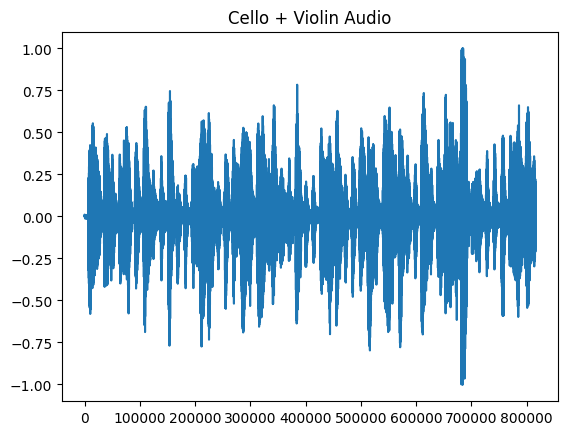

In [3]:
path = '/Users/jasonluo/Documents/JL School/ENEE469O/final_project/data_files/cello_violin_duet.wav'
mixed_signal, sample_rate = librosa.load(path, sr = None)
mixed_signal = mixed_signal[(sample_rate * 7):(sample_rate * 24)]
mixed_signal = mixed_signal / np.abs(np.max(mixed_signal))
display(Audio(mixed_signal, rate = sample_rate))

plt.plot(mixed_signal)
plt.title('Cello + Violin Audio')
plt.show()

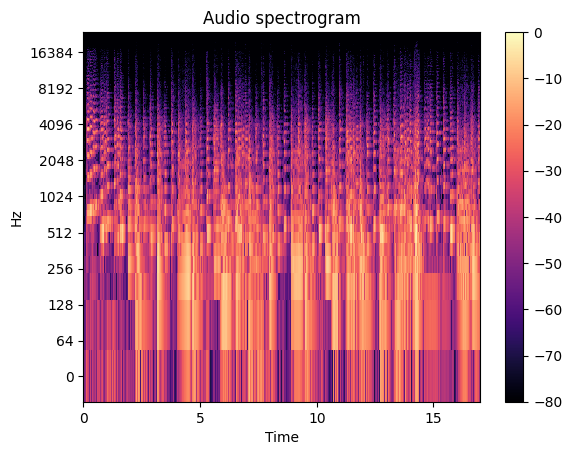

In [4]:
frame_length = 512
hop_length = int(frame_length * 0.25)
sound_stft = librosa.stft(mixed_signal, n_fft=frame_length, hop_length=hop_length)

sound_stft_Magnitude = np.abs(sound_stft)
sound_stft_Angle = np.angle(sound_stft) #Phase

#Plot Log-Scale Spectogram
Spec = librosa.amplitude_to_db(sound_stft_Magnitude, ref = np.max)
img = librosa.display.specshow(Spec,y_axis = 'log',sr=sample_rate,hop_length=hop_length,x_axis ='time')
plt.title('Audio spectrogram')
plt.colorbar(img)
plt.show()

## Convex NMF

  4%|▍         | 190/5000 [17:30<7:23:17,  5.53s/it]

Convergence achieved at iteration 190...


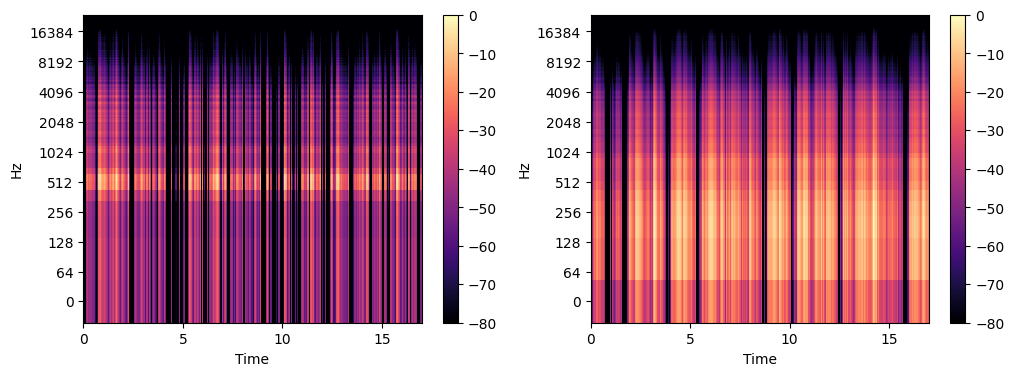

In [5]:
num_sources = 2
CNMF = ConvexNMF(sound_stft_Magnitude, num_sources, 1e-4, 5000, random_state=10)
F, W, G_T, residual_vector_convex = CNMF.factorize()


# Constructing estimated filtered spectrograms
filtered_spectrograms = []
fig, axs = plt.subplots(1, num_sources, figsize = [12, 4])
for i in range(0, num_sources):
    filtered_spectrogram = F[:,[i]] @ G_T[[i],:] # ith Column of W * ith row of H
    D = librosa.amplitude_to_db(filtered_spectrogram, ref = np.max)
    img = librosa.display.specshow(D,y_axis = 'log',sr=sample_rate,hop_length=hop_length,x_axis ='time', ax = axs[i])
    fig.colorbar(img)
    
    filtered_spectrograms.append(filtered_spectrogram)

In [ ]:
# Contructing source sounds using filtered spectograms and phase
new_sounds = []
colors = ['r', 'g']

fig, axs = plt.subplots(1, num_sources, figsize = [15, 7])

for i in range(0, num_sources):
    reconstruct = filtered_spectrograms[i] * np.exp(1j*sound_stft_Angle)
    new_sound = librosa.istft(reconstruct, n_fft = frame_length, hop_length = hop_length)
    new_sounds.append(new_sound)
    axs[i].plot(new_sound, color = colors[i])
    
    display(Audio(new_sounds[i], rate = sample_rate))

In [9]:
G_T_sparse, num_non_zero_G = compute_sparsity(G_T)
F_sparse, num_non_zero_F = compute_sparsity(F)
print(f'Proportion of non-zero elements in  G^T and F: {num_non_zero_G}, {num_non_zero_F}')

for i in range(2):
    __, num_non_zero = compute_sparsity(F[:,[i]] @ G_T[[i], :])
    print(num_non_zero)

Proportion of non-zero elements in  G^T and F: 0.8648055207026348, 0.8346303501945526
0.8326848249027238
0.8365758754863813


## Standard NMF

  1%|          | 31/5000 [00:00<01:16, 65.20it/s]


Convergence achieved at iteration 31...


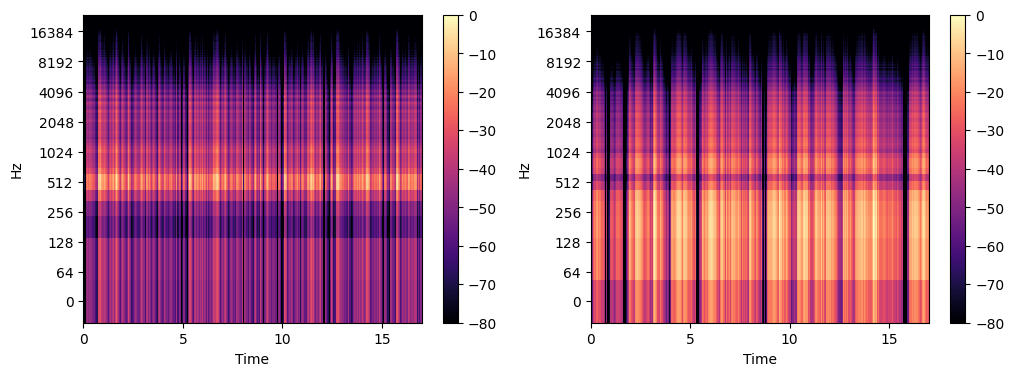

In [10]:
num_sources = 2
model = StandardNMF(sound_stft_Magnitude, num_bases=num_sources, n_iter=5000, tol = 1e-4, random_state = 100)
W, H, residual_vector_standard = model.factorize()

# Constructing estimated filtered spectrograms
filtered_spectrograms = []
fig, axs = plt.subplots(1, num_sources, figsize = [12,4])
for i in range(0, num_sources):
    filtered_spectrogram = W[:,[i]] @ H[[i],:] # ith Column of W * ith row of H
    D = librosa.amplitude_to_db(filtered_spectrogram, ref = np.max)
    img = librosa.display.specshow(D,y_axis = 'log',sr=sample_rate,hop_length=hop_length,x_axis ='time', ax = axs[i])
    fig.colorbar(img)
    
    filtered_spectrograms.append(filtered_spectrogram)

In [ ]:
new_sounds = []
colors = ['r', 'g']

fig, axs = plt.subplots(1, num_sources, figsize = [12 ,4])

for i in range(0, num_sources):
    reconstruct = filtered_spectrograms[i] * np.exp(1j*sound_stft_Angle)
    new_sound = librosa.istft(reconstruct, n_fft = frame_length, hop_length = hop_length)
    new_sounds.append(new_sound)
    axs[i].plot(new_sound, color = colors[i])
    
    display(Audio(new_sounds[i], rate = sample_rate))

plt.tight_layout()

In [12]:
W_sparse, num_non_zero_W = compute_sparsity(W)
H_sparse, num_non_zero_H = compute_sparsity(H)
print(f'Proportion of non-zero elements in  W and H: {num_non_zero_W}, {num_non_zero_H}')

for i in range(2):
    __, num_non_zero = compute_sparsity(W[:,[i]] @ H[[i],:])
    print(num_non_zero)

Proportion of non-zero elements in  W and H: 0.8365758754863813, 0.9783563362609786
0.8365758754863813
0.8365758754863813


Text(0, 0.5, 'Residual ||X - WH||_{F}^2')

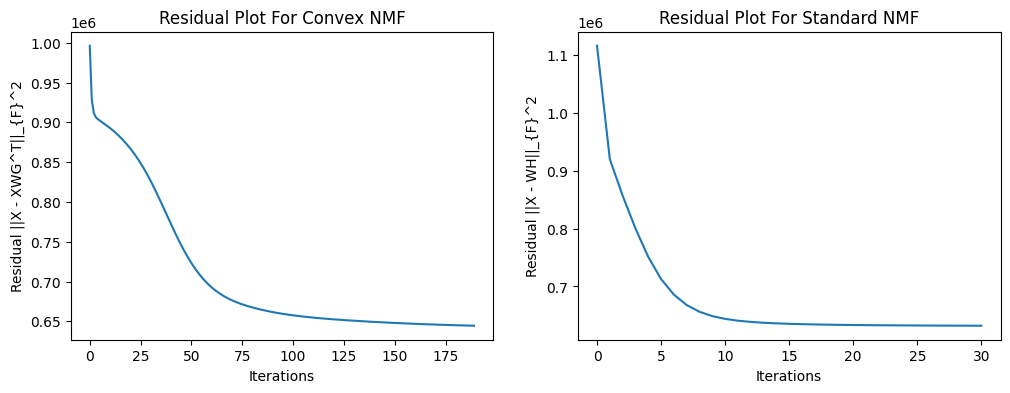

In [13]:
fig, axs = plt.subplots(1, 2, figsize = [12,4])

axs[0].plot(residual_vector_convex)
axs[0].set_title('Residual Plot For Convex NMF')
axs[0].set_xlabel('Iterations')
axs[0].set_ylabel('Residual ||X - XWG^T||_{F}^2')


axs[1].plot(residual_vector_standard)
axs[1].set_title('Residual Plot For Standard NMF')
axs[1].set_xlabel('Iterations')
axs[1].set_ylabel('Residual ||X - WH||_{F}^2')